In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
import joblib
import os

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
X_train = pd.read_csv('../data/processed/X_train_final.csv')
X_val   = pd.read_csv('../data/processed/X_val.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
y_val   = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test  = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print("✅ Data loaded!")
print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

✅ Data loaded!
X_train shape: (107748, 41)
X_val shape:   (26938, 41)
X_test shape:  (22544, 41)


In [3]:
print("⏳ Training Random Forest... (may take 2-3 minutes)")

rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=20,          # max depth of each tree
    random_state=42,       # reproducibility
    n_jobs=-1,             # use all CPU cores for speed
    verbose=1              # show progress
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest trained!")

⏳ Training Random Forest... (may take 2-3 minutes)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.3s


✅ Random Forest trained!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.3s finished


In [4]:
y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:, 1]

print("=" * 45)
print("       RANDOM FOREST RESULTS")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_val, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_val, y_pred)*100:.2f}%")
print(f"Recall:    {recall_score(y_val, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_val, y_pred)*100:.2f}%")
print(f"AUC-ROC:   {roc_auc_score(y_val, y_prob)*100:.2f}%")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Normal', 'Anomaly']))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


       RANDOM FOREST RESULTS
Accuracy:  99.92%
Precision: 99.95%
Recall:    99.89%
F1-Score:  99.92%
AUC-ROC:   100.00%

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
     Anomaly       1.00      1.00      1.00     13469

    accuracy                           1.00     26938
   macro avg       1.00      1.00      1.00     26938
weighted avg       1.00      1.00      1.00     26938



[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


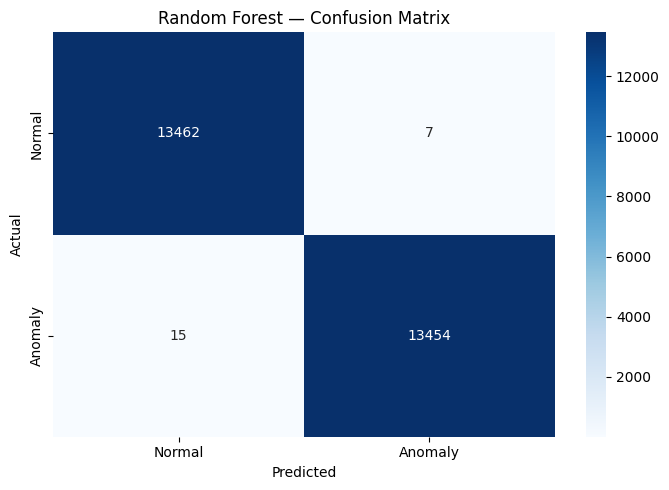


False Positive Rate: 0.05%


In [5]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../docs/rf_confusion_matrix.png')
plt.show()

# False Positive Rate
FP = cm[0][1]
TN = cm[0][0]
FPR = FP / (FP + TN) * 100
print(f"\nFalse Positive Rate: {FPR:.2f}%")

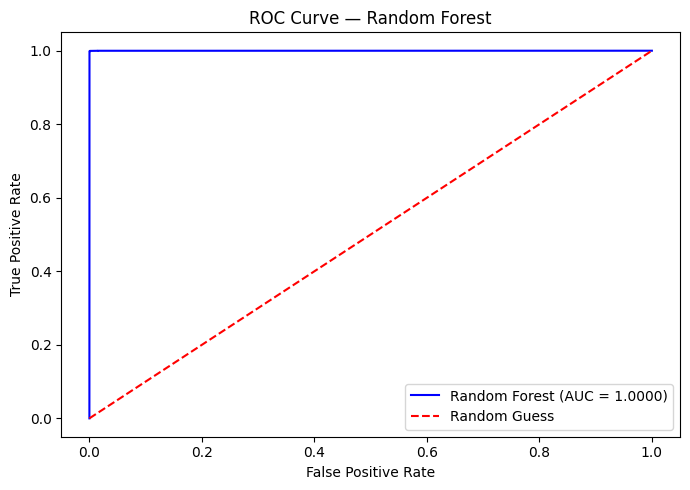

In [6]:
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc_score   = roc_auc_score(y_val, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC Curve — Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/rf_roc_curve.png')
plt.show()

In [7]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_model, '../models/random_forest.pkl')
print("✅ Model saved to models/random_forest.pkl")

✅ Model saved to models/random_forest.pkl
